# Validation of Information Set Lags (Preventing Look-Ahead Bias)

This notebook visualizes the difference between:
- **Physical Ground Truth** (pre-lag, `all_data_refined.parquet`)
- **Model Information Set** (post-lag, `all_data_features.parquet`)

Window: **2025-08-01 06:00 to 20:00 UTC**.


In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.style.use('seaborn-v0_8-paper')
sns.set_context('paper', font_scale=1.15)


In [14]:
# Source A: Physical truth (pre-lag)
from pathlib import Path

candidate_a = [
    'data/processed/all_data_refined.parquet',
    '../data/processed/all_data_refined.parquet',
]

path_a = next((x for x in candidate_a if Path(x).exists()), None)
if path_a is None:
    raise FileNotFoundError(f'Could not find Source A in: {candidate_a}')

# Source B: Model features (post-lag)
candidate_b = [
    'data/processed/all_data_features.parquet',
    'data/features/all_data_features.parquet',
    '../data/processed/all_data_features.parquet',
    '../data/features/all_data_features.parquet',
]

path_b = next((x for x in candidate_b if Path(x).exists()), None)
if path_b is None:
    raise FileNotFoundError(f'Could not find Source B in: {candidate_b}')

required_cols = ['timestamp_utc', 'load_actual_entsoe', 'afrr_activated_mw_pos', 'da_price_eur']

df_a = pd.read_parquet(path_a)
df_b = pd.read_parquet(path_b)

for col in required_cols:
    if col not in df_a.columns:
        raise KeyError(f"Missing '{col}' in Source A ({path_a})")
    if col not in df_b.columns:
        raise KeyError(f"Missing '{col}' in Source B ({path_b})")

for df in (df_a, df_b):
    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True, errors='coerce')
    if df['timestamp_utc'].isna().any():
        raise ValueError('Found invalid timestamps after conversion.')
    df.set_index('timestamp_utc', inplace=True)
    df.sort_index(inplace=True)

print(f"Source A loaded: {path_a} | rows={len(df_a):,}")
print(f"Source B loaded: {path_b} | rows={len(df_b):,}")


Source A loaded: ../data/processed/all_data_refined.parquet | rows=44,568
Source B loaded: ../data/processed/all_data_features.parquet | rows=44,568


In [15]:
# Zoom-in window
start = pd.Timestamp('2025-08-01 06:00:00', tz='UTC')
end = pd.Timestamp('2025-08-01 20:00:00', tz='UTC')

wa = df_a.loc[start:end].copy()
wb = df_b.loc[start:end].copy()

if wa.empty or wb.empty:
    raise ValueError(
        f'Zoom window empty. Source A rows={len(wa)}, Source B rows={len(wb)} for [{start}, {end}]'
    )

print(f'Window A rows: {len(wa)} | Window B rows: {len(wb)}')


Window A rows: 15 | Window B rows: 15


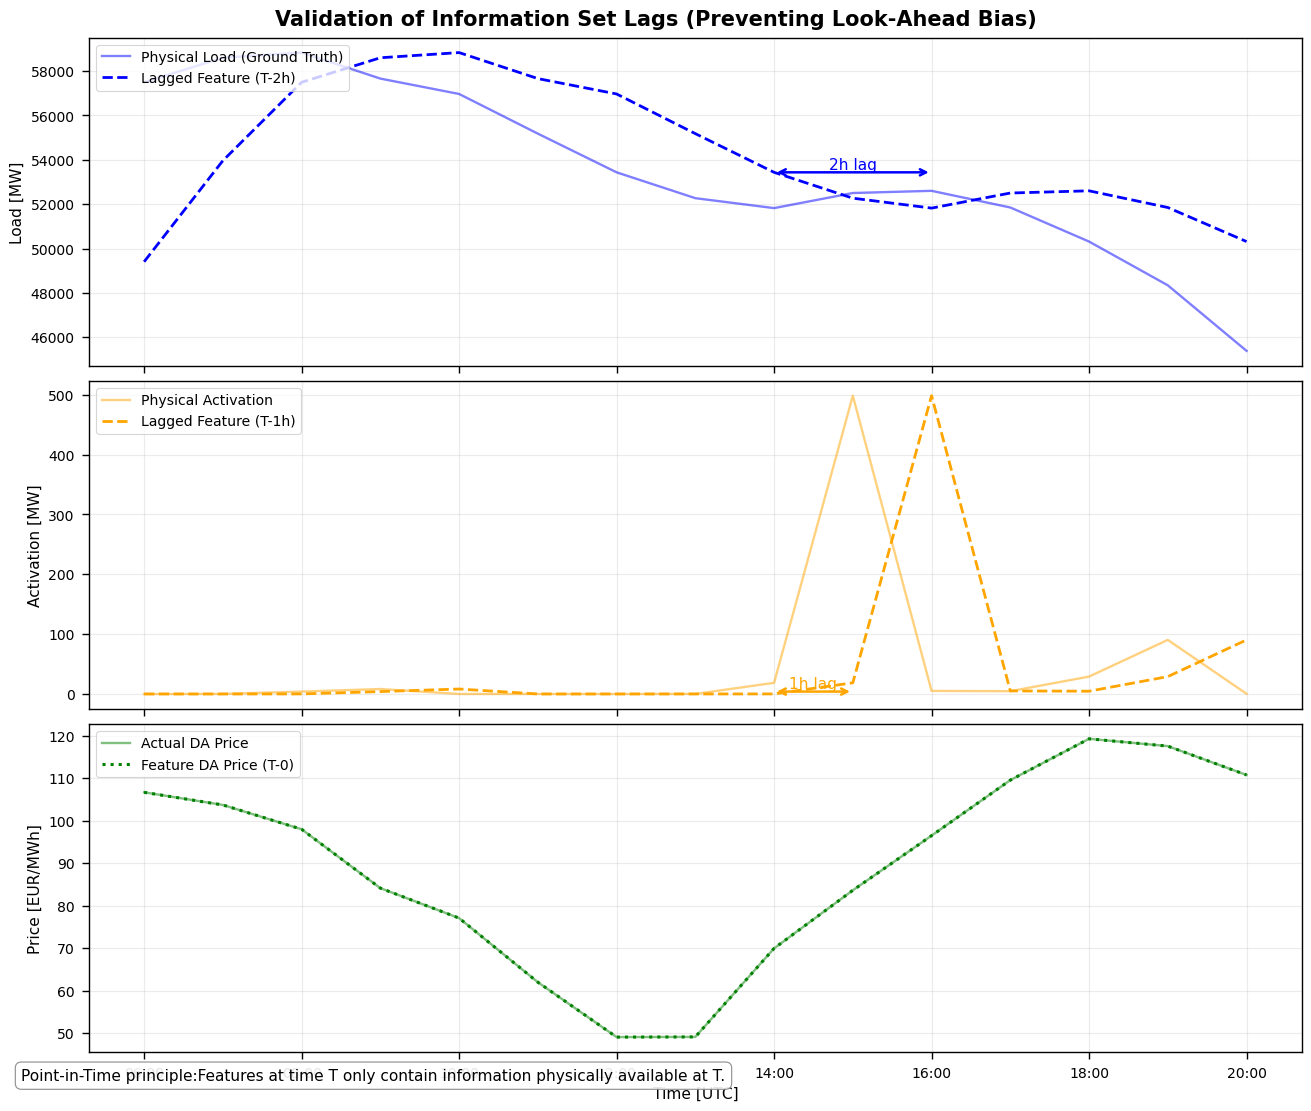

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True, constrained_layout=True)

# ---------------- Panel 1: 2-hour shift ----------------
ax = axes[0]
ax.plot(
    wa.index, wa['load_actual_entsoe'],
    label='Physical Load (Ground Truth)', color='blue', alpha=0.50, linewidth=1.7
)
ax.plot(
    wb.index, wb['load_actual_entsoe'],
    label='Lagged Feature (T-2h)', color='blue', linestyle='--', linewidth=2.0
)
ax.set_ylabel('Load [MW]')
ax.legend(loc='upper left', frameon=True)
ax.grid(alpha=0.25)

x0 = start + pd.Timedelta(hours=8)
x1 = x0 + pd.Timedelta(hours=2)
y0 = float(wb['load_actual_entsoe'].median())
ax.annotate('', xy=(x1, y0), xytext=(x0, y0), arrowprops=dict(arrowstyle='<->', lw=1.8, color='blue'))
ax.text(x0 + pd.Timedelta(hours=1), y0, '2h lag', color='blue', ha='center', va='bottom')

# ---------------- Panel 2: 1-hour shift ----------------
ax = axes[1]
ax.plot(
    wa.index, wa['afrr_activated_mw_pos'],
    label='Physical Activation', color='orange', alpha=0.50, linewidth=1.7
)
ax.plot(
    wb.index, wb['afrr_activated_mw_pos'],
    label='Lagged Feature (T-1h)', color='orange', linestyle='--', linewidth=2.0
)
ax.set_ylabel('Activation [MW]')
ax.legend(loc='upper left', frameon=True)
ax.grid(alpha=0.25)

x0 = start + pd.Timedelta(hours=8)
x1 = x0 + pd.Timedelta(hours=1)
y1 = float(wb['afrr_activated_mw_pos'].median())
ax.annotate('', xy=(x1, y1), xytext=(x0, y1), arrowprops=dict(arrowstyle='<->', lw=1.8, color='orange'))
ax.text(x0 + pd.Timedelta(minutes=30), y1, '1h lag', color='orange', ha='center', va='bottom')

# ---------------- Panel 3: 0-hour alignment ----------------
ax = axes[2]
ax.plot(
    wa.index, wa['da_price_eur'],
    label='Actual DA Price', color='green', alpha=0.50, linewidth=1.7
)
ax.plot(
    wb.index, wb['da_price_eur'],
    label='Feature DA Price (T-0)', color='green', linestyle=':', linewidth=2.2
)
ax.set_ylabel('Price [EUR/MWh]')
ax.legend(loc='upper left', frameon=True)
ax.grid(alpha=0.25)

# Global formatting
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=mdates.UTC))
axes[2].set_xlabel('Time [UTC]')

fig.suptitle('Validation of Information Set Lags (Preventing Look-Ahead Bias)', fontsize=15, fontweight='bold')

textbox = (
    'Point-in-Time principle:'
    'Features at time T only contain information physically available at T.'
)
fig.text(
    0.012, 0.02, textbox,
    ha='left', va='bottom',
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.4')
)

plt.show()


In [17]:
# Optional quantitative overlap check for the T-0 panel
common = wa[['da_price_eur']].join(wb[['da_price_eur']], lsuffix='_a', rsuffix='_b', how='inner')
max_abs_diff = (common['da_price_eur_a'] - common['da_price_eur_b']).abs().max()
print(f'Max absolute difference (DA T-0): {max_abs_diff:.6f} EUR/MWh')


Max absolute difference (DA T-0): 0.000000 EUR/MWh


## Automated Data Integrity Audit

This section performs a **cell-by-cell mathematical audit** of the Lag-First policy.

Ground Truth (GT): `data/processed/all_data_refined.parquet`  
Feature Set (FE): `data/processed/all_data_features.parquet`

Audit rules:
- **2H group:** `FE[C]_t = GT[C]_(t-2)`
- **1H group:** `FE[C]_t = GT[C]_(t-1)`
- **0H group (strict synchronous):** `FE[C]_t = GT[C]_t`
- **Target group:** `FE[target_X_h]_t = GT[y_true_X]_(t+h)`, `h in [1,72]`

Tolerance: `1e-9` (boundary NaNs ignored).


In [18]:
import re
from pathlib import Path
import numpy as np
import pandas as pd

GT_CANDIDATES = ['data/processed/all_data_refined.parquet', '../data/processed/all_data_refined.parquet']
FE_CANDIDATES = ['data/processed/all_data_features.parquet', '../data/processed/all_data_features.parquet']

GT_PATH = next((p for p in GT_CANDIDATES if Path(p).exists()), None)
FE_PATH = next((p for p in FE_CANDIDATES if Path(p).exists()), None)
if GT_PATH is None:
    raise FileNotFoundError(f'Could not find GT file in: {GT_CANDIDATES}')
if FE_PATH is None:
    raise FileNotFoundError(f'Could not find FE file in: {FE_CANDIDATES}')

TOL_POLICY = 1e-9
TOL_DERIVED = 1e-7


def _load_for_audit(gt_path: str, fe_path: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    gt = pd.read_parquet(gt_path)
    fe = pd.read_parquet(fe_path)
    for df in (gt, fe):
        if 'timestamp_utc' not in df.columns:
            raise KeyError('Missing timestamp_utc in audit source.')
        df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True, errors='coerce')
        if df['timestamp_utc'].isna().any():
            raise ValueError('Invalid timestamp_utc values found.')
        df.set_index('timestamp_utc', inplace=True)
        df.sort_index(inplace=True)
    return gt, fe


def _is_derived_name(col: str) -> bool:
    return any(tok in col for tok in ['_mean_', '_std_', '_rolling_', '_volatility_', '_log1p'])


def _group_and_expected_lag(col: str) -> tuple[str, int | None, str | None]:
    m_pos = re.fullmatch(r'target_pos_h(\d+)', col)
    if m_pos:
        h = int(m_pos.group(1))
        if 1 <= h <= 72:
            return 'TARGET', -h, 'y_true_pos'

    m_neg = re.fullmatch(r'target_neg_h(\d+)', col)
    if m_neg:
        h = int(m_neg.group(1))
        if 1 <= h <= 72:
            return 'TARGET', -h, 'y_true_neg'

    if _is_derived_name(col):
        return 'DERIVED', None, None

    if (
        '_actual_entsoe' in col
        or 'generation_fossil_' in col
        or col == 'generation_nuclear_mw'
        or 'generation_hydro_' in col
        or col == 'residual_load_actual'
        or col == 'NRV_balance'
        or col == 'residual_load_calc'
    ):
        return '2H', 2, col

    if (
        'afrr_activated_mw' in col
        or 'mfrr_activated_mw' in col
        or 'afrr_marginal_activation_price' in col
        or 'afrr_activation_marginal_price' in col
        or 'afrr_vwap' in col
        or 'reBAP_shortage_surplus' in col
        or 'afrr_picasso_mw' in col
        or col == 'price_intraday_eur'
    ):
        return '1H', 1, col

    if (
        col in {'da_price_eur', 'da_price', 'da_price_d_eur_mwh'}
        or (col.startswith('da_price_') and not _is_derived_name(col))
        or col.startswith('afrr_capacity_price_')
        or (('capacity' in col) and not _is_derived_name(col))
        or col in {'gas_price_ttf', 'coal_price_api2', 'co2_price_eua'}
    ):
        return '0H', 0, col

    return 'UNMAPPED', None, None


def _max_abs_error(fe_s: pd.Series, ref_s: pd.Series) -> float:
    f, r = fe_s.align(ref_s, join='inner')
    valid = f.notna() & r.notna()
    if valid.sum() == 0:
        return 0.0
    return float((pd.to_numeric(f[valid], errors='coerce') - pd.to_numeric(r[valid], errors='coerce')).abs().max())


def _infer_applied_lag(fe_s: pd.Series, ref_s: pd.Series, candidate_lags: list[int]) -> tuple[int | None, float]:
    best_lag = None
    best_err = float('inf')
    for lag in candidate_lags:
        e = _max_abs_error(fe_s, ref_s.shift(lag))
        if e < best_err:
            best_err = e
            best_lag = lag
    return best_lag, best_err


def _audit_derived_column(col: str, fe: pd.DataFrame) -> tuple[float, str]:
    if col == 'da_price_volatility_30d':
        price_col = next((c for c in ('da_price', 'da_price_d_eur_mwh', 'da_price_eur') if c in fe.columns), None)
        if price_col is None:
            return np.inf, 'FAIL'
        expected = fe[price_col].shift(24).rolling(window=720, min_periods=1).std(ddof=1)
        err = _max_abs_error(fe[col], expected)
        return err, ('PASS' if err <= TOL_DERIVED else 'FAIL')

    derived_specs = {
        'load_actual_entsoe_mean_24h': ('load_actual_entsoe', 24, 'mean'),
        'load_actual_entsoe_std_24h': ('load_actual_entsoe', 24, 'std'),
        'load_actual_entsoe_mean_168h': ('load_actual_entsoe', 168, 'mean'),
        'load_actual_entsoe_std_168h': ('load_actual_entsoe', 168, 'std'),
        'da_price_eur_mean_24h': ('da_price_eur', 24, 'mean'),
        'da_price_eur_std_24h': ('da_price_eur', 24, 'std'),
        'da_price_eur_mean_168h': ('da_price_eur', 168, 'mean'),
        'da_price_eur_std_168h': ('da_price_eur', 168, 'std'),
        'wind_onshore_actual_entsoe_mean_24h': ('wind_onshore_actual_entsoe', 24, 'mean'),
        'wind_onshore_actual_entsoe_std_24h': ('wind_onshore_actual_entsoe', 24, 'std'),
        'wind_onshore_actual_entsoe_mean_168h': ('wind_onshore_actual_entsoe', 168, 'mean'),
        'wind_onshore_actual_entsoe_std_168h': ('wind_onshore_actual_entsoe', 168, 'std'),
    }
    if col in derived_specs:
        base_col, window, op = derived_specs[col]
        if base_col not in fe.columns:
            return np.inf, 'FAIL'
        expected = fe[base_col].rolling(window=window, min_periods=(1 if op == 'mean' else 2)).mean() if op == 'mean' else fe[base_col].rolling(window=window, min_periods=2).std(ddof=1)
        err = _max_abs_error(fe[col], expected)
        return err, ('PASS' if err <= TOL_DERIVED else 'FAIL')

    return np.nan, 'SKIP'


def run_full_audit(df_refined: pd.DataFrame, df_features: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for col in df_features.columns:
        group, expected_lag, source_col = _group_and_expected_lag(col)

        if group == 'UNMAPPED':
            rows.append({'Column': col, 'Group': group, 'Applied Lag': np.nan, 'Expected Lag': np.nan, 'Max Error': np.nan, 'Status': 'SKIP'})
            continue

        if group == 'DERIVED':
            err, st = _audit_derived_column(col, df_features)
            rows.append({'Column': col, 'Group': group, 'Applied Lag': np.nan, 'Expected Lag': np.nan, 'Max Error': err, 'Status': st})
            continue

        if group == 'TARGET':
            # Targets are generated inside feature pipeline. Prefer FE y_true_* as reference source.
            if source_col in df_features.columns:
                ref_base = df_features[source_col]
            elif source_col in df_refined.columns:
                ref_base = df_refined[source_col]
            else:
                rows.append({'Column': col, 'Group': group, 'Applied Lag': np.nan, 'Expected Lag': expected_lag, 'Max Error': np.inf, 'Status': 'FAIL'})
                continue
            h = -int(expected_lag)
            expected = ref_base.shift(-h)
            max_err = _max_abs_error(df_features[col], expected)
            status = 'PASS' if max_err <= TOL_POLICY else 'FAIL'
            rows.append({'Column': col, 'Group': group, 'Applied Lag': np.nan, 'Expected Lag': expected_lag, 'Max Error': max_err, 'Status': status})
            continue

        if source_col not in df_refined.columns:
            rows.append({'Column': col, 'Group': group, 'Applied Lag': np.nan, 'Expected Lag': expected_lag, 'Max Error': np.inf, 'Status': 'FAIL'})
            continue

        fe_s = df_features[col]
        gt_s = df_refined[source_col]
        expected = gt_s.shift(int(expected_lag))
        max_err = _max_abs_error(fe_s, expected)
        applied_lag, _ = _infer_applied_lag(fe_s, gt_s, [0, 1, 2, 3, 4])

        status = 'PASS' if max_err <= TOL_POLICY else 'FAIL'
        if group in {'1H', '2H'} and status == 'FAIL' and applied_lag is not None and applied_lag > int(expected_lag):
            status = 'FAIL_DOUBLE_LAG'

        rows.append({'Column': col, 'Group': group, 'Applied Lag': applied_lag, 'Expected Lag': expected_lag, 'Max Error': max_err, 'Status': status})

    report = pd.DataFrame(rows)

    # D+3 forecast gate audit
    forecast_candidates = ['load_forecast_da_entsoe', 'wind_forecast_da_entsoe', 'wind_onshore_forecast_da_entsoe', 'solar_forecast_da_entsoe']
    present = [c for c in forecast_candidates if c in df_features.columns and c in df_refined.columns]
    if present:
        idx_local = df_features.index.tz_convert('Europe/Berlin')
        local_hour = pd.Series(idx_local.hour, index=df_features.index)
        hours_to_next_da_pub = np.where(local_hour < 13, 13 - local_hour, 37 - local_hour)
        known_horizon = pd.Series(hours_to_next_da_pub + 24, index=df_features.index)

        for c in present:
            expected_gate = pd.Series(np.where(known_horizon < 72, df_refined[c].shift(24), df_refined[c]), index=df_features.index).ffill()
            gate_err = _max_abs_error(df_features[c], expected_gate)
            gate_status = 'PASS' if gate_err <= TOL_POLICY else 'FAIL'

            mask_active = known_horizon < 72
            gt_now = df_refined[c]
            gt_prev_day = df_refined[c].shift(24)
            informative = mask_active & gt_now.notna() & gt_prev_day.notna() & ((gt_now - gt_prev_day).abs() > TOL_POLICY)
            if informative.any():
                leaked = ((df_features[c] - gt_now).abs() <= TOL_POLICY) & informative
                if leaked.any():
                    gate_status = 'FAIL'

            report = pd.concat([
                report,
                pd.DataFrame([{'Column': c, 'Group': 'D+3_GATE', 'Applied Lag': np.nan, 'Expected Lag': np.nan, 'Max Error': gate_err, 'Status': gate_status}])
            ], ignore_index=True)

    report = report.sort_values(['Status', 'Group', 'Column'], kind='mergesort').reset_index(drop=True)
    return report


GT, FE = _load_for_audit(GT_PATH, FE_PATH)
audit_report = run_full_audit(GT, FE)

print('Full audit summary:')
print(audit_report['Status'].value_counts(dropna=False))

display(audit_report)

policy_groups = ['2H', '1H', '0H', 'D+3_GATE']
policy_report = audit_report[audit_report['Group'].isin(policy_groups)].copy()
info_report = audit_report[audit_report['Group'].isin(['TARGET', 'DERIVED', 'UNMAPPED'])].copy()

print('\nPolicy-gate summary (hard pass/fail):')
print(policy_report['Status'].value_counts(dropna=False))

print('\nInformational summary (targets/derived/unmapped):')
print(info_report['Status'].value_counts(dropna=False))

non_target_fail = policy_report[policy_report['Status'].isin(['FAIL', 'FAIL_DOUBLE_LAG'])]
if not non_target_fail.empty:
    raise ValueError('Lag-First policy audit failed. ' f'Fail count: {len(non_target_fail)}')

if 'da_price_eur' in GT.columns and 'da_price_eur' in FE.columns:
    da_err = _max_abs_error(FE['da_price_eur'], GT['da_price_eur'])
    if da_err > TOL_POLICY:
        raise ValueError(f'da_price_eur violates strict T-0 overlap. Max Error: {da_err}')

print('\nAutomated Data Integrity Audit PASSED (policy groups).')


Full audit summary:
Status
PASS    219
SKIP     82
Name: count, dtype: int64


,Column,Group,Applied Lag,Expected Lag,Max Error,Status
0,afrr_capacity_awarded_mw_neg,0H,0.0,0.0,0.0,PASS
1,afrr_capacity_awarded_mw_pos,0H,0.0,0.0,0.0,PASS
2,afrr_capacity_offered_mw_neg,0H,0.0,0.0,0.0,PASS
3,afrr_capacity_offered_mw_pos,0H,0.0,0.0,0.0,PASS
4,afrr_capacity_price_neg,0H,0.0,0.0,0.0,PASS
...,...,...,...,...,...,...
296,wind_total_error_da,UNMAPPED,NaN,NaN,NaN,SKIP
297,y_train_neg,UNMAPPED,NaN,NaN,NaN,SKIP
298,y_train_pos,UNMAPPED,NaN,NaN,NaN,SKIP
299,y_true_neg,UNMAPPED,NaN,NaN,NaN,SKIP



Policy-gate summary (hard pass/fail):
Status
PASS    62
Name: count, dtype: int64

Informational summary (targets/derived/unmapped):
Status
PASS    157
SKIP     82
Name: count, dtype: int64

Automated Data Integrity Audit PASSED (policy groups).
